In [12]:
import cpip
import importlib
import ipywidgets as widgets
import plotly.graph_objects as go
from IPython.display import display
from traitlets import HasTraits, Int
import ipywidgets as w
import time
import numpy as np
importlib.reload(cpip)

<module 'cpip' from 'C:\\Users\\PC\\Desktop\\PYTHON\\cpip.py'>

In [199]:
class LQR():
    def __init__(self, reference=[0,0,0,0], k=[0,0,0,0], max_torque=500, limit_theta_abs=25):
        self.reference = np.array(reference, dtype=float)
        self.k = np.array(k, dtype=float)
        self.max_torque = max_torque
        self.limit_theta_abs = limit_theta_abs
        self.dt_average = 0.003110208693771676
        self.current_time = 0
        self.last_time = 0
        self.dt = 0
        self.last_theta = 0
        self.last_x = 0
        self.actionPx = 0
        self.actionDx = 0
        self.actionPth = 0
        self.actionDth = 0
        self.action = 0
        #self.x_dot = 0
        self.theta_dot = 0
        self.history = []
        self.list = []
        
    def set_gains(self, k):
        self.k = np.array(k, dtype=float)
        
    def set_reference(self, reference):
        self.reference = np.array(reference, dtype=float)
        
    def __call__(self, theta, x, new_turn):
        self.current_time = time.perf_counter()
        self.dt = self.current_time - self.last_time
        self.last_time = self.current_time

        if new_turn:
            self.history = []
            self.dt = self.dt_average
            self.last_x = x
            self.last_theta = theta
    
        x_dot = (x - self.last_x) / self.dt 
        theta_dot = (theta - self.last_theta) / self.dt
        alpha = 0.4  # Tuning parameter, adjust if needed
        #self.x_dot = alpha * ((x - self.last_x) / self.dt) + (1 - alpha) * self.x_dot
        self.theta_dot = alpha * ((theta - self.last_theta) / self.dt) + (1 - alpha) * self.theta_dot

        state = np.array([x*0.001, x_dot*0.001, np.radians(theta), np.radians(self.theta_dot)])

        ref_error = state - self.reference
        
        self.actionPx = self.k[0] * ref_error[0]  
        self.actionDx = self.k[1] * ref_error[1]  
        self.actionPth = self.k[2] * ref_error[2] 
        self.actionDth = self.k[3] * ref_error[3] 

        self.action = -(self.actionPx + self.actionDx + self.actionPth + self.actionDth)
        #self.history.append((self.action, x*0.001, x_dot*0.001, np.radians(theta), np.radians(theta_dot), self.dt))
        self.history.append((self.action, self.actionPx, self.actionDx, self.actionPth, self.actionDth,self.dt))
        
        self.last_theta = theta
        self.last_x = x
    
        return self.action
        
controller = LQR()        

In [224]:
controller.set_gains([-20.1421, -83.2811, 441.3666, 170.3917])
controller.set_reference([0.27, 0, np.pi, 0])

In [225]:
driver = cpip.MotorDriver(controller=controller, max_torque=800, limit_theta_abs=16)

Пронајдени се повеќе етернет адаптери, го користиме последниот во листата \Device\NPF_{74130C1F-BE8D-4666-A8B2-86775047A9D5}.
Пронајден е двигателот на моторот.
Корисникот претерал со вртежниот момент.


Exception in thread Thread-26 (watchdog):
Traceback (most recent call last):
  File "C:\Users\PC\miniforge3\envs\pytorch-env\lib\threading.py", line 1016, in _bootstrap_inner
    self.run()
  File "C:\Users\PC\miniforge3\envs\pytorch-env\lib\site-packages\ipykernel\ipkernel.py", line 766, in run_closure
    _threading_Thread_run(self)
  File "C:\Users\PC\miniforge3\envs\pytorch-env\lib\threading.py", line 953, in run
    self._target(*self._args, **self._kwargs)
  File "C:\Users\PC\Desktop\PYTHON\cpip.py", line 140, in watchdog
    theta = self.read_theta()
  File "C:\Users\PC\Desktop\PYTHON\cpip.py", line 114, in read_theta
    u_pulses = self.read_theta_encoder()
  File "C:\Users\PC\Desktop\PYTHON\cpip.py", line 108, in read_theta_encoder
    pulses = self.slave.sdo_read(EXTERNAL_ENCODER, SUBINDEX)
  File "src\\pysoem\\pysoem.pyx", line 742, in pysoem.pysoem.CdefSlave.sdo_read
  File "src\\pysoem\\pysoem.pyx", line 1082, in pysoem.pysoem.CdefSlave._raise_exception
pysoem.pysoem.Emerg

In [226]:
driver.read_theta()

0.0

In [229]:
driver.read_x()

276.6288125

In [242]:
controller.set_gains([-130, -60, 800, 77])

In [243]:
controller.k

array([-130.,  -60.,  800.,   77.])

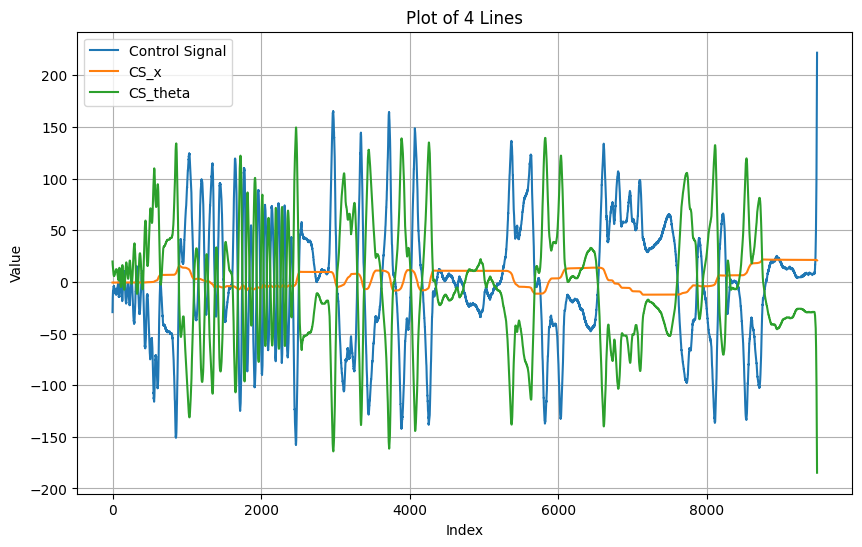

In [235]:
import matplotlib.pyplot as plt

# Unpack data into individual lists for each line
line1, line2, line3, line4, line5, line6 = zip(*controller.history)

# Create an index for the x-axis (e.g., steps or time)
x_values = list(range(len(controller.history)))

# Plotting the 4 lines
plt.figure(figsize=(10, 6))

    
plt.plot(x_values, line1, label="Control Signal")
plt.plot(x_values, line2, label="CS_x")
#plt.plot(x_values, line3, label="CS_x_dot")
plt.plot(x_values, line4, label="CS_theta")
#plt.plot(x_values, line5, label="CS_theta_dot")

# Adding titles and labels
plt.title("Plot of 4 Lines")
plt.xlabel("Index")
plt.ylabel("Value")

# Adding a legend
plt.legend()

# Show the plot
plt.grid(True)
plt.show()


In [170]:
import matplotlib.pyplot as plt

def plot_history(action, x_m, x_dot_m, theta_rad, theta_dot_rad, dt):
    """
    Plots action, x_m, x_dot_m, theta_rad, and theta_dot_rad over time.
    
    Parameters:
    - action: List or array of control actions (torque)
    - x_m: List or array of positions in meters
    - x_dot_m: List or array of velocities in meters/second
    - theta_rad: List or array of angles in radians
    - theta_dot_rad: List or array of angular velocities in radians/second
    - dt: List or array of time steps
    """
    # Generate time vector based on dt
    time = [sum(dt[:i+1]) for i in range(len(dt))]  # cumulative sum of dt to represent the time

    # Create figure and subplots
    fig, axs = plt.subplots(3, 2, figsize=(10, 8))
    
    # Plotting action vs time
    axs[0, 0].plot(time, action, label='Action (Torque)', color='b')
    axs[0, 0].set_title("Action (Torque) over Time")
    axs[0, 0].set_xlabel('Time (s)')
    axs[0, 0].set_ylabel('Action')
    axs[0, 0].grid(True)
    
    # Plotting x_m vs time
    axs[0, 1].plot(time, x_m, label='Position (x_m)', color='g')
    axs[0, 1].set_title("Position (x_m) over Time")
    axs[0, 1].set_xlabel('Time (s)')
    axs[0, 1].set_ylabel('Position (m)')
    axs[0, 1].grid(True)
    
    # Plotting x_dot_m vs time
    axs[1, 0].plot(time, x_dot_m, label='Velocity (x_dot_m)', color='r')
    axs[1, 0].set_title("Velocity (x_dot_m) over Time")
    axs[1, 0].set_xlabel('Time (s)')
    axs[1, 0].set_ylabel('Velocity (m/s)')
    axs[1, 0].grid(True)
    
    # Plotting theta_rad vs time
    axs[1, 1].plot(time, theta_rad, label='Angle (theta_rad)', color='orange')
    axs[1, 1].set_title("Angle (theta_rad) over Time")
    axs[1, 1].set_xlabel('Time (s)')
    axs[1, 1].set_ylabel('Angle (rad)')
    axs[1, 1].grid(True)
    
    # Plotting theta_dot_rad vs time
    axs[2, 0].plot(time, theta_dot_rad, label='Angular Velocity (theta_dot_rad)', color='purple')
    axs[2, 0].set_title("Angular Velocity (theta_dot_rad) over Time")
    axs[2, 0].set_xlabel('Time (s)')
    axs[2, 0].set_ylabel('Angular Velocity (rad/s)')
    axs[2, 0].grid(True)
    
    # Hide empty subplot
    axs[2, 1].axis('off')
    
    # Adjust layout to make room for the titles
    plt.tight_layout()
    plt.show()


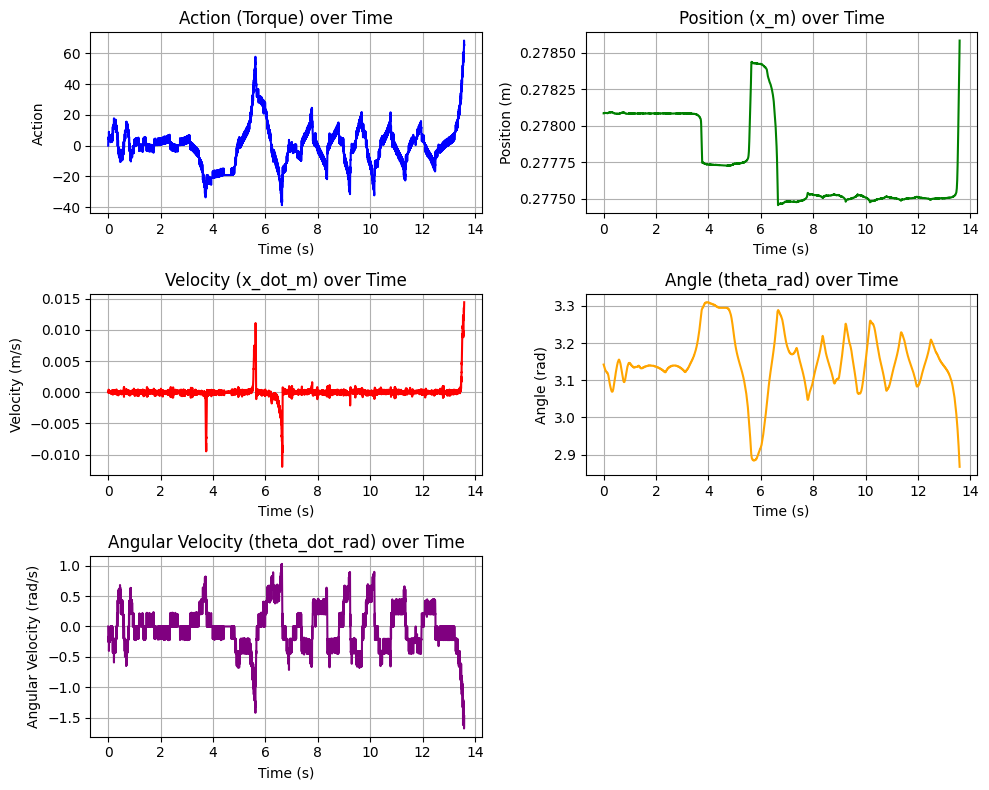

In [171]:
action, x_m, x_dot_m, theta_rad, theta_dot_rad, dt = zip(*controller.history)

plot_history(action, x_m, x_dot_m, theta_rad, theta_dot_rad, dt)